# 모든 단어를 토큰으로 변환

# https://tiktokenizer.vercel.app/

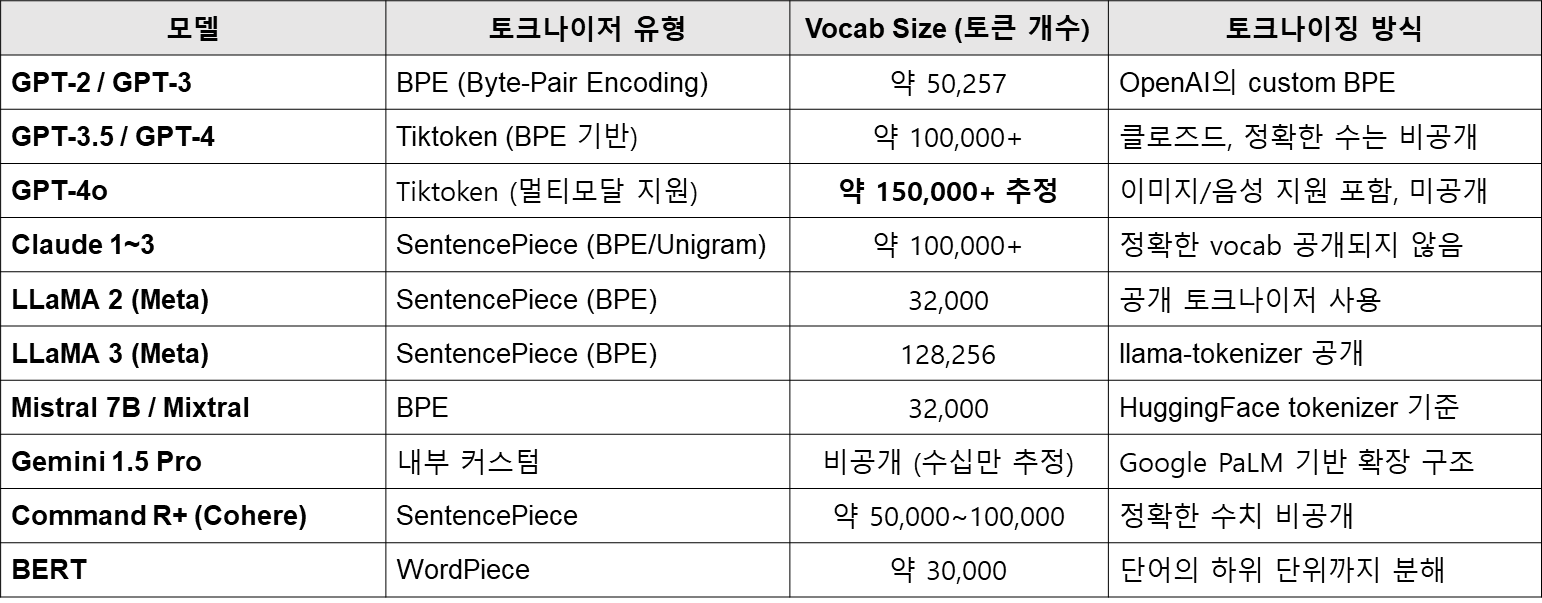

# **LLM 모델의 크기는 가중치 갯수**

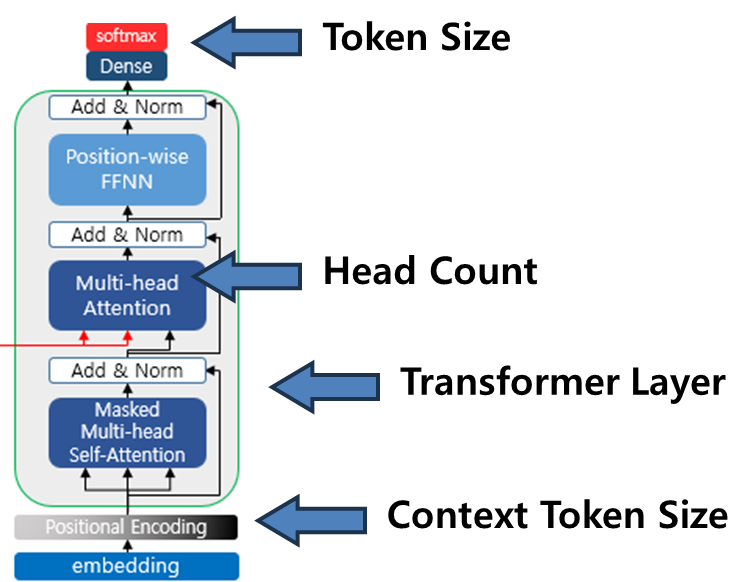

# **Scaling Law : LLM 크기를 키우면 성능이 좋아짐**

| 모델명                      | Input Token 길이 (Context Length) | Output Token 최대치  | 어텐션 헤드 수 (Heads) | 히든 크기 (Hidden Size) | 레이어 수 (Layers) | 파라미터 수 (Parameters)    |
| ------------------------ | ------------------------------- | ----------------- | ---------------- | ------------------- | -------------- | ---------------------- |
| **GPT-1 (2018)**         | 512                             | ~256              | 12               | 768                 | 12             | **117M**               |
| **GPT-2 XL (2019)**      | 1,024                           | ~512              | 25               | 1,600               | 48             | **1.5B**               |
| **GPT-3 Davinci (2020)** | 2,048                           | ~1,024            | 96               | 12,288              | 96             | **175B**               |
| **GPT-3.5 (2022)**       | 4,096                           | ~2,048            | 비공개              | 비공개                 | 비공개            | **20B~30B 추정**         |
| **GPT-4 (2023)**         | 8,192                           | ~4,096            | 비공개              | 비공개                 | 비공개            | **1.8T MoE(전문가 수십 개)** |
| **GPT-4 (32K)**          | 32,768                          | ~16,000           | 비공개              | 비공개                 | 비공개            | 동일                     |
| **GPT-4o (2024)**        | 128,000                         | **~65,536**       | 비공개              | 비공개                 | 비공개            | **40B 단일 모델**          |
| **GPT-4.1 (2024)**       | 128,000                         | **~65,536**       | 비공개              | 비공개                 | 비공개            | **~100B 단일 모델 추정**     |
| **GPT-5 (2025)**         | **200,000**                     | **~100,000 (추정)** | 비공개              | 비공개                 | 비공개            | **200B~350B 추정**       |


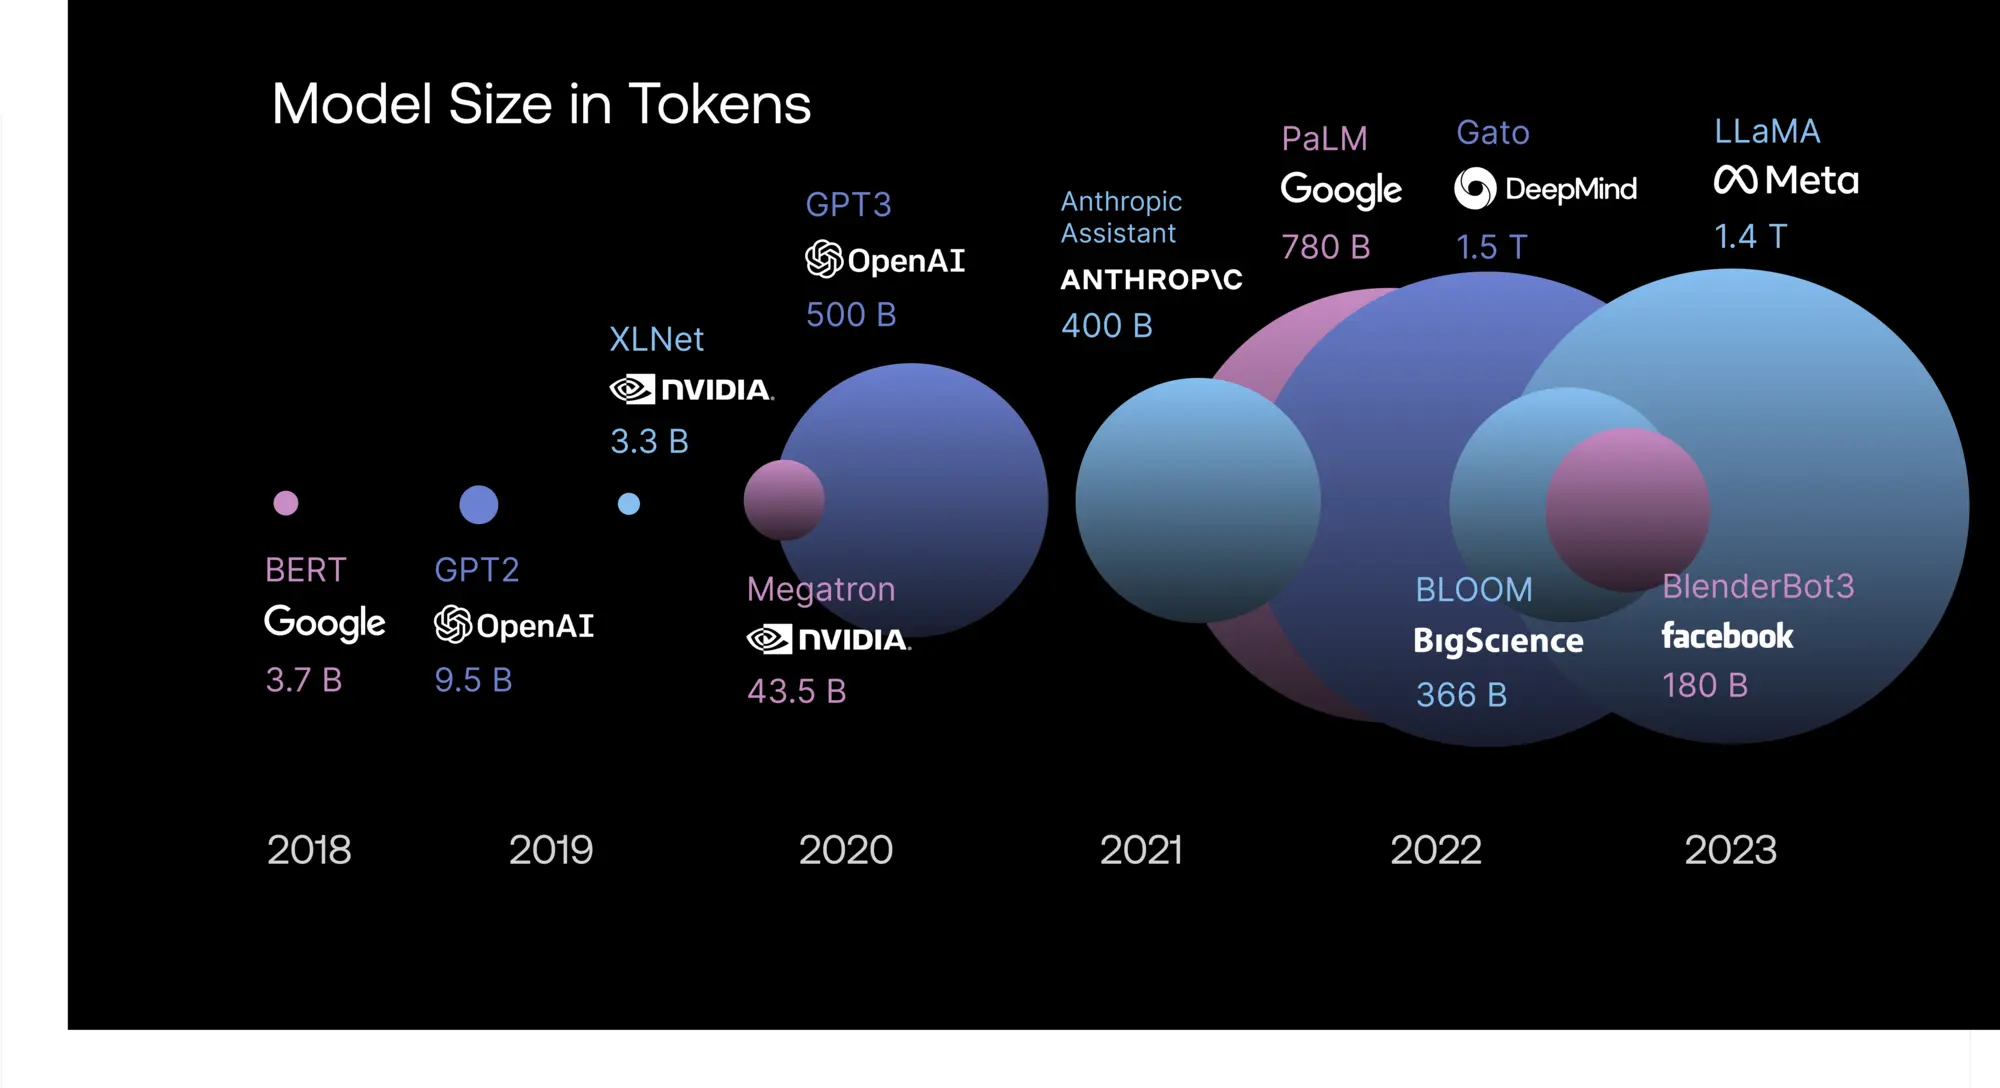

https://scale.com/guides/large-language-models

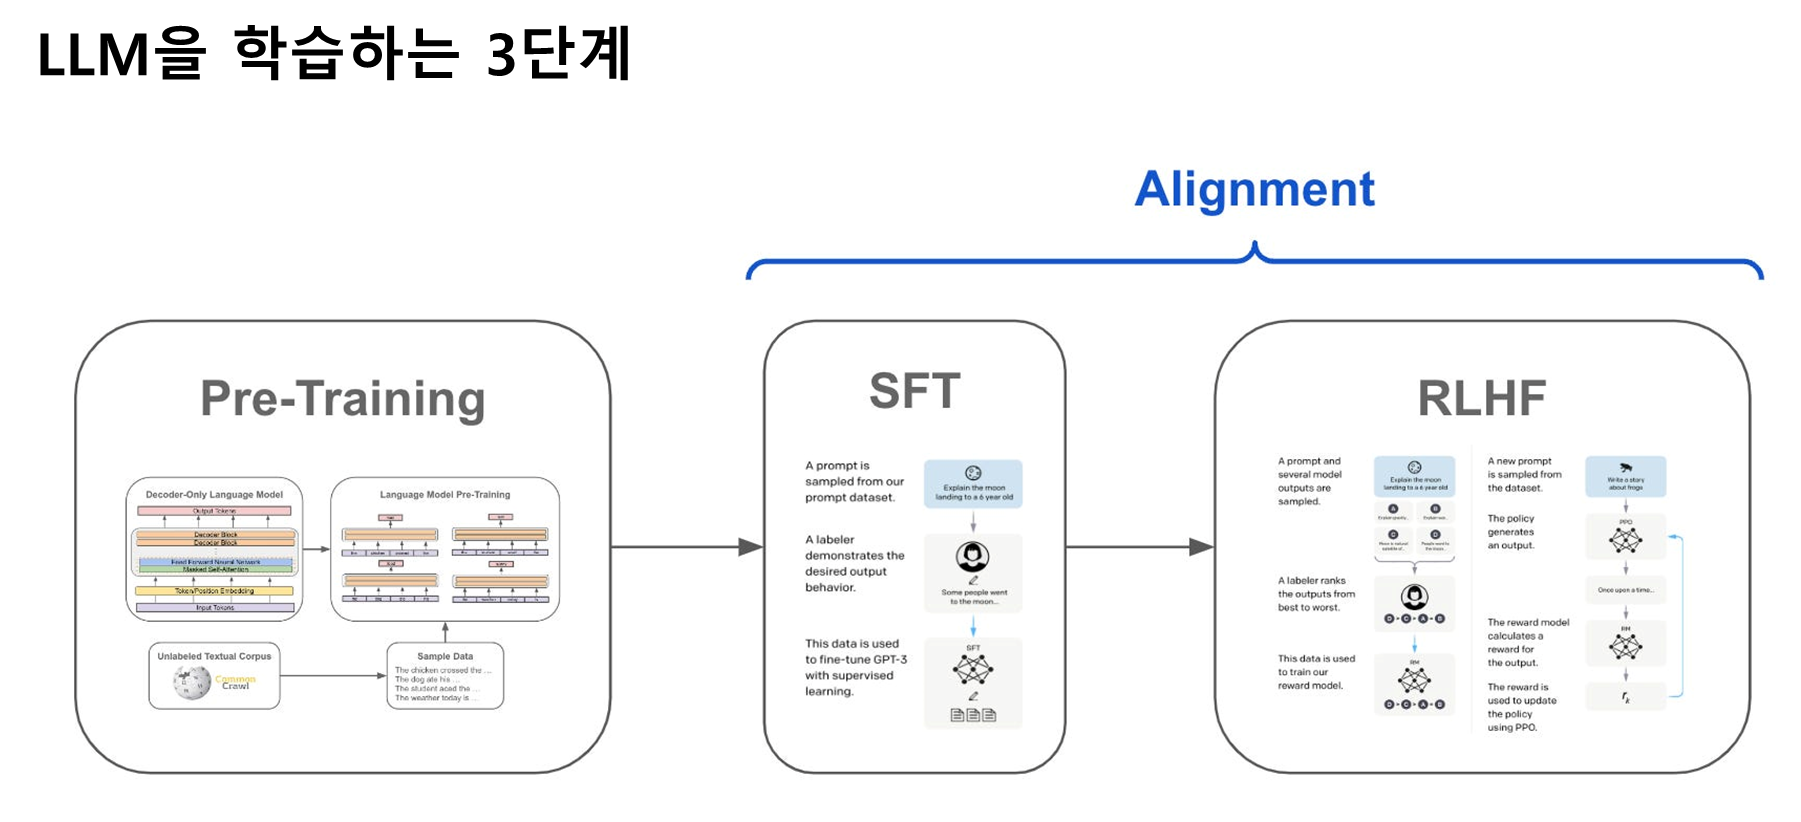

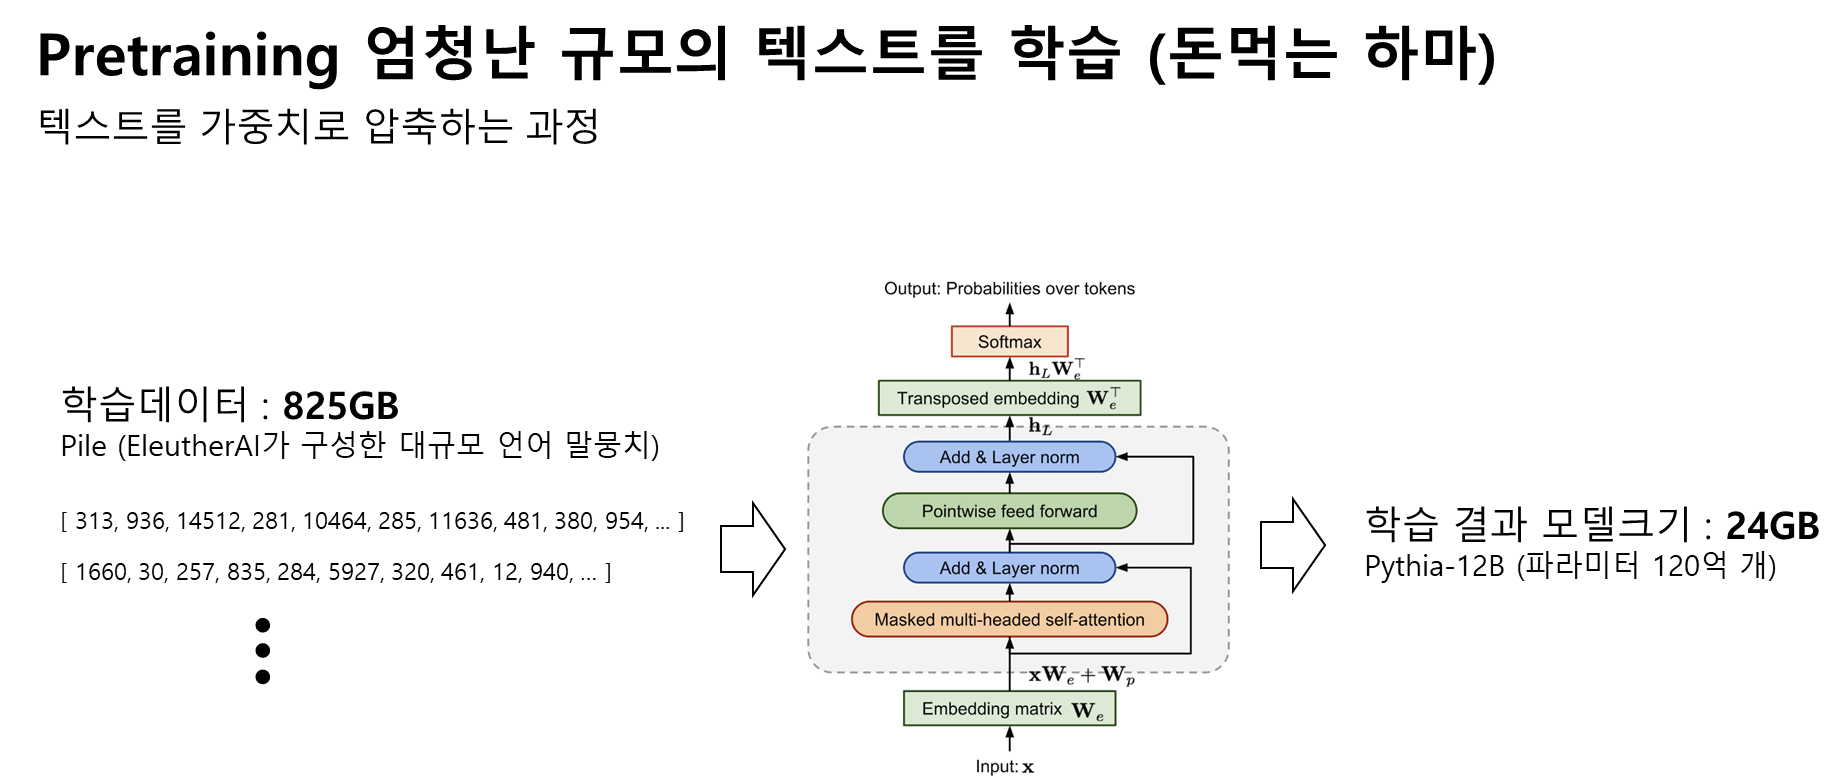

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "gpt2"  #
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


In [ ]:

txt = "If we can’t accept limitations, then we’re "
inputs = tokenizer(txt, return_tensors="pt")

print("")
print("input token : " + str(inputs))
print("")


outputs = model.generate(**inputs)
print("")
print("outputs token : " + str(outputs))
print("")

print(tokenizer.decode(outputs[0]))
print("")

In [ ]:

txt = "Never say good bye because goodbye means "
inputs = tokenizer(txt, return_tensors="pt")

print("")
print("input token : " + str(inputs))
print("")


outputs = model.generate(**inputs)
print("")
print("outputs token : " + str(outputs))
print("")

print(tokenizer.decode(outputs[0]))
print("")

| 모델                       | 파라미터 수 | 대략 사용된 GPU 수                                   | 대략 학습 기간                                     | 비용/컴퓨트 규모                                                                                            | 비고                                           |
| ------------------------ | ------ | ---------------------------------------------- | -------------------------------------------- | ---------------------------------------------------------------------------------------------------- | -------------------------------------------- |
| Llama 3.1 405B (Meta AI) | 405 B  | 약 **16,000**개 H100 GPU ([NVIDIA Developer][1]) | 약 **54일** (보고서상) ([Data Center Dynamics][2]) | 약 **30.84 백만 GPU시간** ([The Register][3]) <br>또 다른 언급에선 GPU 장비만 “$400 million 어치” 사용 ([TweakTown][4]) | 토큰 수 15 조 이상 ([The Register][3])             |
| GPT‑4 (OpenAI)           | (비공개)  | 약 **25,000** A100 GPU (추정) ([젠스파크][5])         | 약 **90~100일** (추정) ([젠스파크][5])               | 비용이 수천만 달러대 (“tens of millions of USD”) ([arXiv][6])                                                 | 공식 GPT-4 기술문서에선 상세 GPU/시간 정보 미공개 ([위키백과][7]) |
| 일반적인 비용 추정 / 연구          | —      | —                                              | —                                            | 예: 2024년 연구에서는 “최대 규모 모델 비용은 수천만 달러”라고 분석 ([arXiv][6])                                               |                                              |

[1]: https://developer.nvidia.com/blog/supercharging-llama-3-1-across-nvidia-platforms/?utm_source=chatgpt.com "Supercharging Llama 3.1 across NVIDIA Platforms"
[2]: https://www.datacenterdynamics.com/en/news/meta-report-details-hundreds-of-gpu-and-hbm3-related-interruptions-to-llama-3-training-run/?utm_source=chatgpt.com "Meta report details hundreds of GPU and HBM3 related ..."
[3]: https://www.theregister.com/2024/07/23/meta_llama31_405b/?utm_source=chatgpt.com "Meta says all new Llama 3.1 405B model bests OpenAI's ..."
[4]: https://www.tweaktown.com/news/99506/meta-releases-worlds-largest-ai-model-trained-on-400-million-worth-of-gpus/index.html?utm_source=chatgpt.com "Meta releases 'world's largest' AI model trained on $400 ..."
[5]: https://www.genspark.ai/spark/how-many-gpus-are-needed-to-train-gpt4-o/56c3b449-f206-495f-bc9b-d06812bf4a33?utm_source=chatgpt.com "How Many Gpus Are Needed To Train Gpt4-O"
[6]: https://arxiv.org/html/2405.21015v1?utm_source=chatgpt.com "The rising costs of training frontier AI models"
[7]: https://en.wikipedia.org/wiki/GPT-4?utm_source=chatgpt.com "GPT-4"


# **SFT Supervised Fine Tunning**

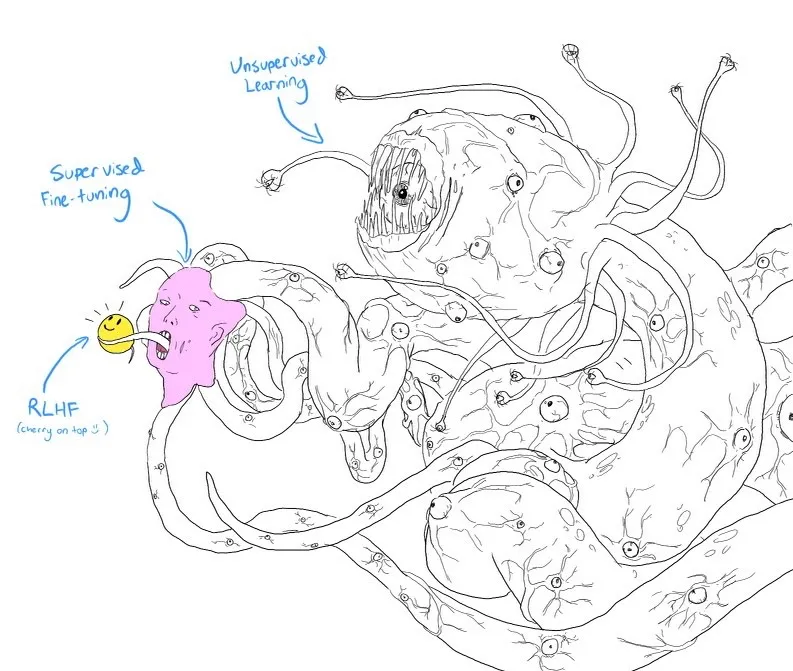

https://kevinmunger.substack.com/p/ban-llms-using-first-person-pronouns

# **SFT : 대화형태로 감독 학습 = Caht 모델**

# https://huggingface.co/datasets/allenai/olmo-2-hard-coded

# **SFT : Reasoning 형태로 감독 합습 = Reasoning 모델**

## https://huggingface.co/datasets/PRIME-RL/Eurus-2-SFT-Data?utm_source=chatgpt.com

# **사람의 피드백을 받아서 강화학습**

# **RLHF** Reinforcement learning from human feedback

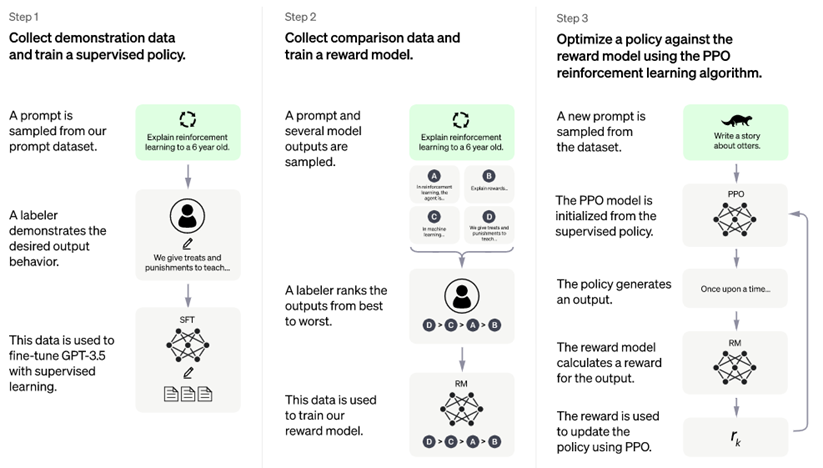

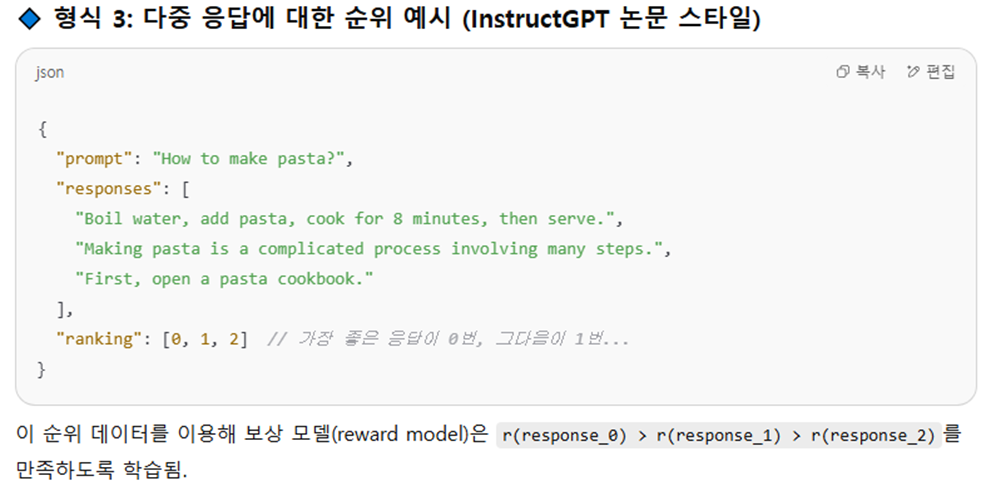

# **DeepSeek가 적용에 성공한 **
## RLVR (Reinforcement Learning from Verifiable Rewards)**굵은 텍스트**

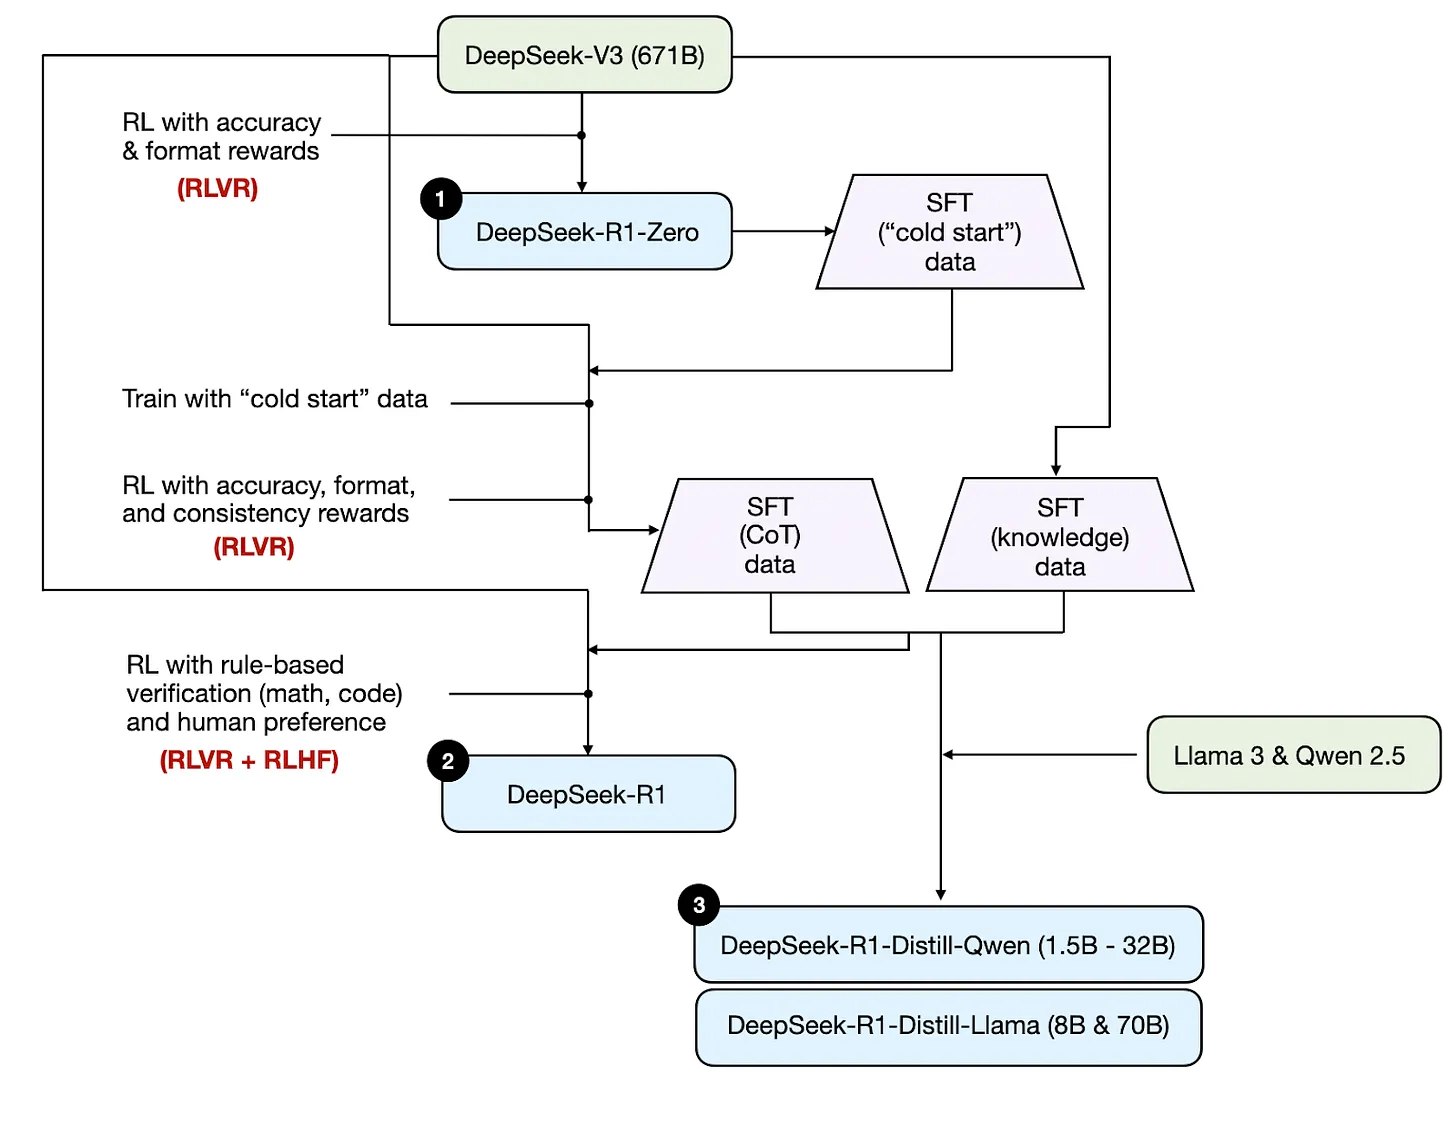

https://magazine.sebastianraschka.com/p/the-state-of-llm-reasoning-model-training?utm_source=chatgpt.com

#**DeepSeek MoE (Mixture-ofExperts)**

전문 분야별로 분리해서 학습해서 추론(Inference)시에 비용을 절약

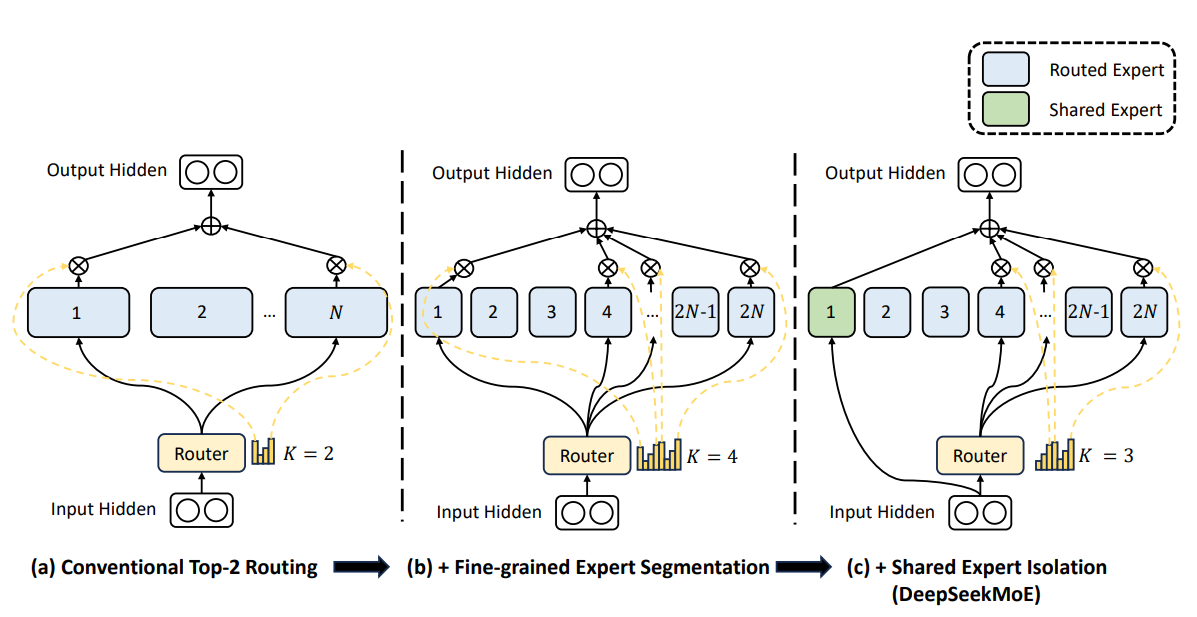

https://arxiv.org/abs/2401.06066?utm_source=chatgpt.com

# **PEFT (Parameter Efficient fine tuning)**

## **1) LORA (Low-Rank Adaptation)**

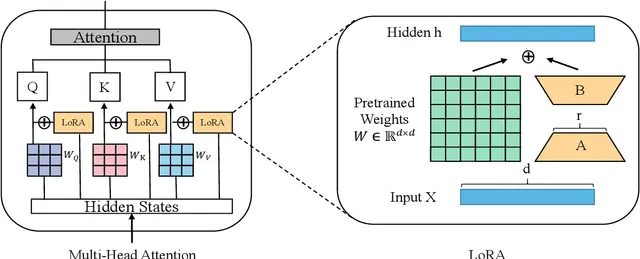

# **https://www.aporia.com/learn/low-rank-adaptation-lora/**

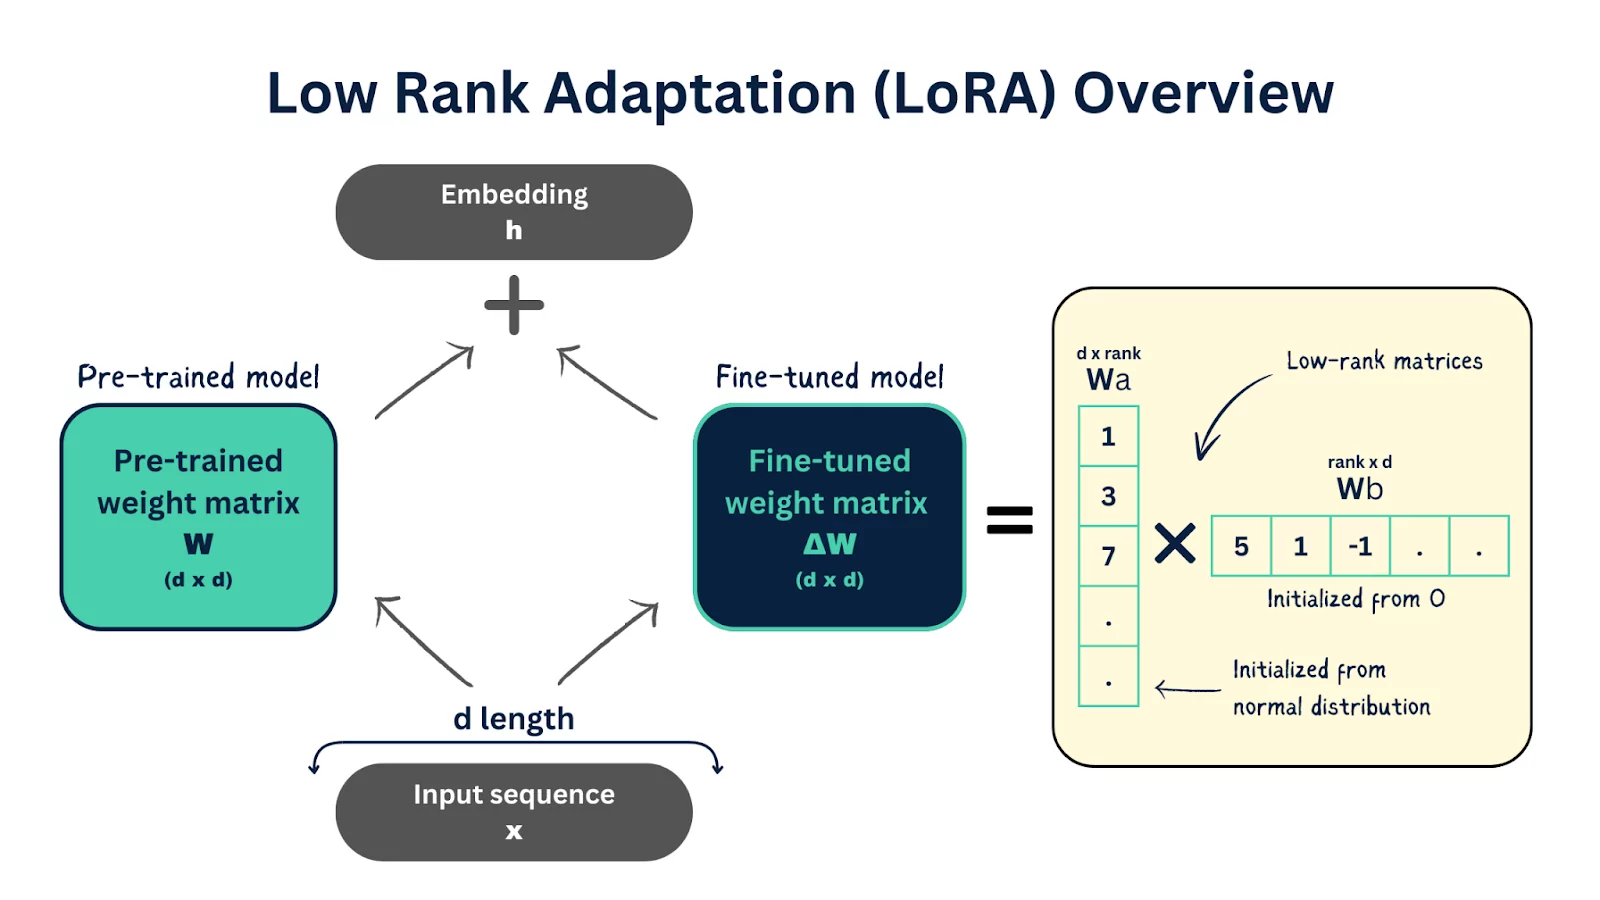

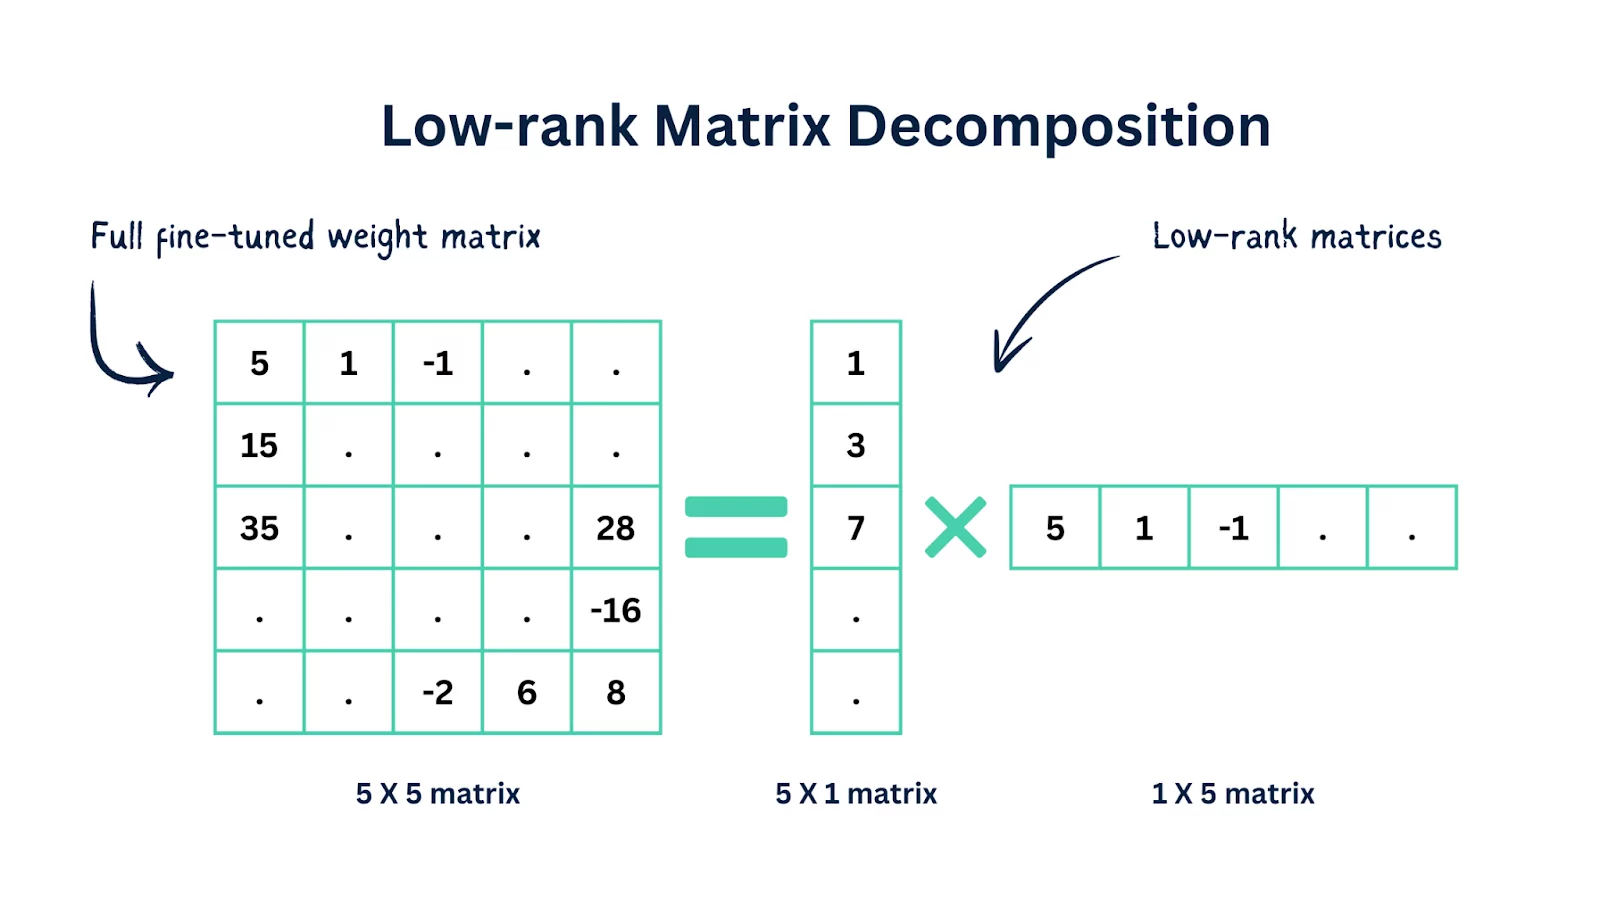

## **2) Adapter Modules(어댑터 모듈)**

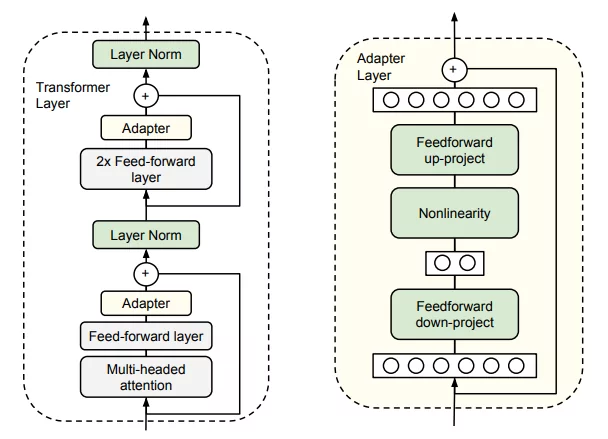

## **3) 양자화**

# **https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-quantization**

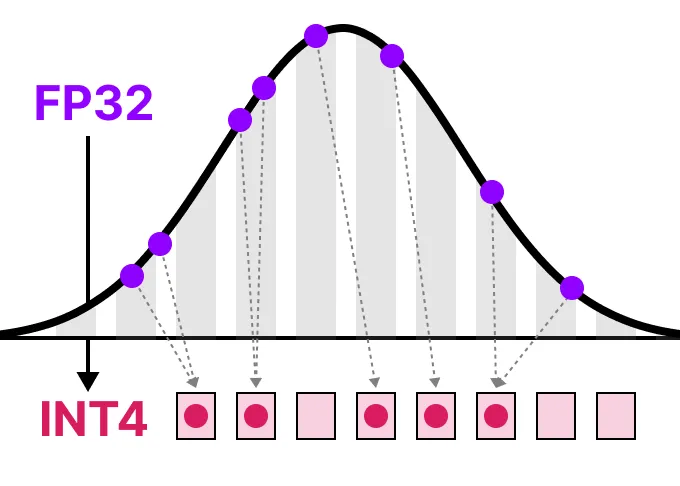

## **https://m.blog.naver.com/oniontime/223539614844**

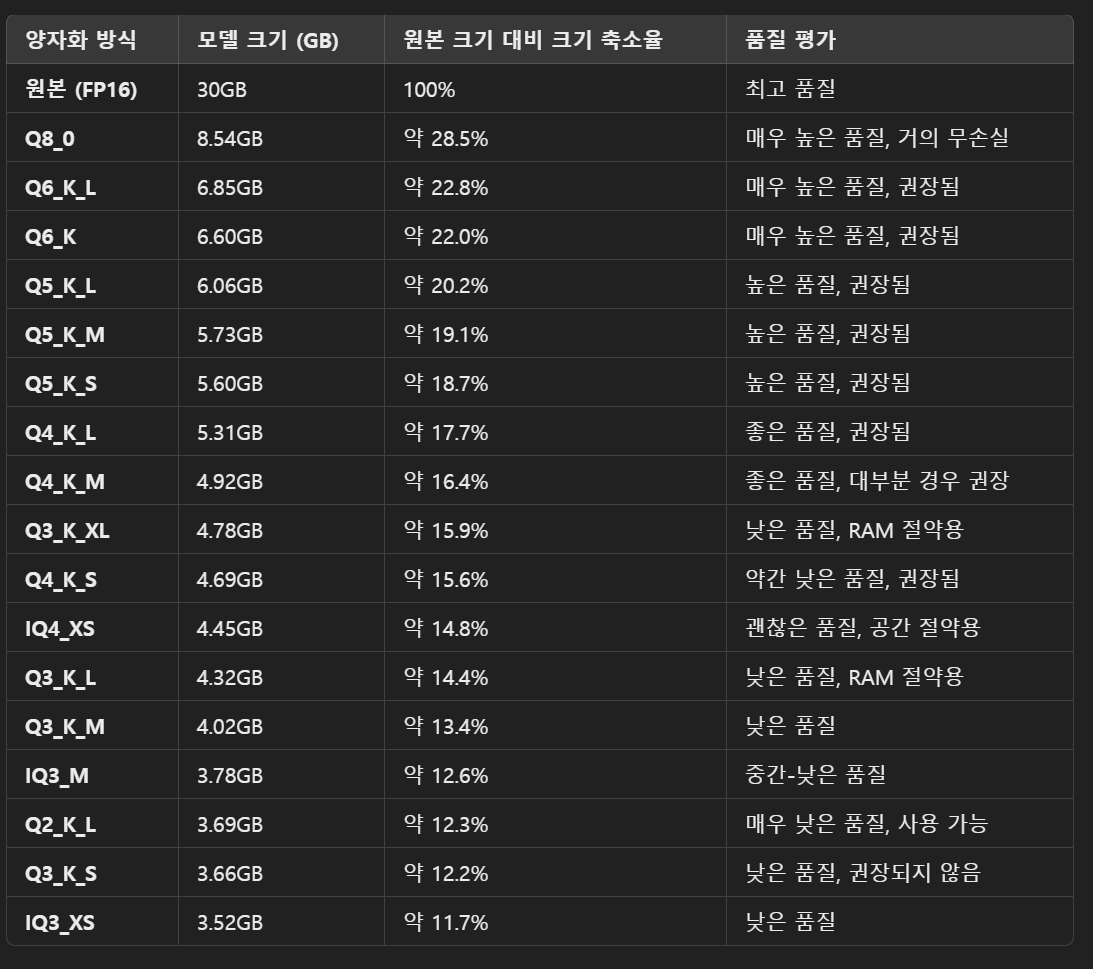
